# Учебная задача: Анализ сайта «СберАвтоподписка»

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
RANDOM_STATE = 42

## Добываем признаки успешного действия. 

Выберем из исходных данных ga_hits.csv информативные сгруппированные столбцы: event_action, event_category и частоту (то есть количество сессий, в которых произошло событие). Выбирать необходимо чанками, так как датасет слишком большой.

In [3]:
from collections import Counter

chunk_size = 100000
all_actions = Counter()
for chunk in pd.read_csv('data/ga_hits.csv', usecols=['session_id', 'event_action', 'event_category'], chunksize=chunk_size, low_memory=False):
    grouped = chunk.groupby(['event_category', 'event_action'])['session_id'].count()
    all_actions.update(grouped.to_dict())

Мы получили большой счетчик с ключами из кортежей (event_category, event_action) и частотой в качестве значения. Преобразуем его в DataFrame для удобства.

In [4]:
df_actions = pd.DataFrame([
    {
        'event_category': key[0],
        'event_action': key[1],
        'frequency': val
    }
    for key, val in all_actions.items()
])

df_actions = df_actions.sort_values(by='frequency', ascending=False).reset_index(drop=True)
print(f"Всего видов действий на платформе: {df_actions.shape[0]}")

Всего видов действий на платформе: 245


Посмотрим на топ 10 записей.

In [5]:
df_actions.head(10)

,event_category,event_action,frequency
0,card_web,view_card,3558985
1,card_web,view_new_card,3551009
2,sub_page_view,sub_landing,1798117
3,listing_ads,go_to_car_card,973666
4,sub_button_click,sub_view_cars_click,791515
5,search_form,search_form_region,512069
6,search_form,search_form_search_btn,433748
7,sap_search_form,sap_search_form_cost_to,356596
8,search_form,showed_number_ads,326274
9,cars,pagination_click,248944


В несколько итераций, собираем все ключевые слова, которые позволят пометить ненужные нам действия как шум. 

In [6]:
noise_regexes = ["search|quiz|go_to|photo|view|show|pagination|credit|page|ads|faq|link|sort|more",
                "scrolling|message|landing|banner|start|entered|offer|click_on|get|gift|rejected|typing|menu",
                "return|incorrect|add_ad|sms|initiate|select|button|share|pos|label|auto|tap_on|requested|buyback",
                "prechat|need|jivo_|close|error|titul|rules|mobile|click_sell|answer|document|back_to|calculate",
                "forward|free|change|failed|setelem|help|invitation|insurance|auth_success|continue"]

noise_regex = "|".join(noise_regexes)
action_is_noise = df_actions['event_action'].str.contains(noise_regex)
category_is_noise = df_actions['event_category'].str.contains("add_ad_|landing")

df_actions['noise'] = np.where(action_is_noise, 1, 0)
df_actions['noise'] = np.where((df_actions['noise'] == 1) | category_is_noise, 1, 0)

print(f"Осталось {df_actions[df_actions["noise"] == 0].shape[0]} событий")
df_actions[df_actions["noise"] == 0].sort_values(by='event_category').head(30)

Осталось 18 событий


,event_category,event_action,frequency,noise
192,greenday_gtm.triggergroup,greenday_sub_open_dialog_click,21,0
143,greenday_gtm.triggergroup,greenday_sub_callback_submit_click,167,0
215,greenday_gtm.triggergroup,greenday_sub_submit_success,3,0
109,greenday_sub_button_click,greenday_sub_callback_submit_click,783,0
157,greenday_sub_button_click,greenday_sub_open_dialog_click,63,0
217,greenday_sub_button_click,greenday_sub_call_number_click,3,0
114,greenday_sub_submit,greenday_sub_submit_success,695,0
91,jivosite,chat established,2066,0
113,jivosite,user gave contacts during chat,715,0
178,phone,form_request_call_sent,34,0


Ручная фильтрация оставила нам 18 целевых действий: 7 целевых действий акции greenday; 2 действия в категории живосайт (онлайн-общение с оператором в чате); запрос на звонок, 7 действий группы sub_button_click (здесь и отправки формы, и нажатие на номер телефона для связи с оператором и открытие диалогового окна) и финальное sub_submit_success - удачно завершившаяся отрпавка формы на сайте.

Преобразуем эти действия в список для создания таргета.

In [7]:
target_actions = list(df_actions[df_actions["noise"] == 0]["event_action"])
target_actions

['sub_car_claim_click',
 'sub_open_dialog_click',
 'sub_submit_success',
 'sub_car_claim_submit_click',
 'sub_call_number_click',
 'sub_callback_submit_click',
 'sub_car_request_submit_click',
 'chat established',
 'greenday_sub_callback_submit_click',
 'user gave contacts during chat',
 'greenday_sub_submit_success',
 'sub_custom_question_submit_click',
 'greenday_sub_callback_submit_click',
 'greenday_sub_open_dialog_click',
 'form_request_call_sent',
 'greenday_sub_open_dialog_click',
 'greenday_sub_submit_success',
 'greenday_sub_call_number_click']

## Создаем таргет - целевые действия в сервисе
Данных очень много. df_hits будем загружать чанками по 100000 записей.

In [8]:
chunk_size = 100000

target_sessions = set()
for chunk in pd.read_csv('data/ga_hits.csv', usecols=['session_id', 'event_action'], chunksize=chunk_size, low_memory=False):
    target_rows = chunk[chunk['event_action'].isin(target_actions)]
    target_sessions.update(target_rows['session_id'].unique())

Помечаем сессию как успешную или неуспешную

In [9]:
df_sessions = pd.read_pickle('data/ga_sessions.pkl')
df_sessions['is_target'] = df_sessions['session_id'].isin(target_sessions).astype(int)

Сохраним обработанный df_sessions на диск, чтобы не перечитывать ga_hits при каждом запуске ноутбука

In [10]:
df_sessions.to_pickle('data/sessions_with_target.pkl')

Загрузим сессии с меткой таргета.

In [11]:
df = pd.read_pickle('data/sessions_with_target.pkl')

## Исследование и анализ датасета

In [12]:
print(f"Имеем датасет размера: {df.shape}")

Имеем датасет размера: (1860042, 19)


Всего 19 признаков. Оценим их природу.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 19 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
 18  is_target                 int64 
dtypes: int64(2), object(17)
memory usage: 269.6+ MB


Посмотрим есть ли в данных дубликаты по session_id

In [14]:
unique_sessions = df['session_id'].nunique()
print(f"Всего дубликатов сессий: {df.shape[0] - unique_sessions}")

Всего дубликатов сессий: 0


Проверим пропуски.

In [15]:
missing_data = df.isna().mean()*100
print("Процент пропусков по колонкам:")
print(missing_data[missing_data > 0].sort_values(ascending=False))

Процент пропусков по колонкам:
device_model     99.121633
utm_keyword      58.174009
device_os        57.533002
utm_adcontent    18.043410
utm_campaign     11.806346
device_brand      6.380394
utm_source        0.005215
dtype: float64


Колонка device_model пуста на 99%. 

utm_keyword (ключевые слова при переходе) пуста на 58%, это потому что не все сессии стартуют с перехода по рекламной ссылке.

device_os (операционная система устройства) так же пуста почти на 58%. 

Оценим природу данных в этих столбцах.

In [16]:
display(df["device_model"].value_counts().head(3))
display(df["utm_keyword"].value_counts().head(3))

device_model
AuMdmADEIoPXiWpTsBEj    9778
tWBQlsvNfHxRUjaPAfhd     653
cwMJxNXiWUgMUxGiCTPs     651
Name: count, dtype: int64

utm_keyword
puhZPIYqKXeFPaUviSjo    506819
aXQzDWsJuGXeBXexNHjc     24241
pHqgLcdBQPSLcrTpLkdr     13767
Name: count, dtype: int64

Данные категориальные, повторяющиеся и хэшированые. 

Посмотрим на другое категориальные данные:

In [17]:
scip_list = ['session_id', 'client_id', 'visit_date', 'visit_time', 'device_model', 'utm_keyword']
for column in df.columns:
    if (column not in scip_list) and (df[column].dtype == 'object'):
        display(df[column].value_counts().head(5))
        display(f"Всего категорий в признаке {len(df[column].value_counts())}")
        display("="*40)

utm_source
ZpYIoDJMcFzVoPFsHGJL    578290
fDLlAcSmythWSCVMvqvL    300575
kjsLglQLzykiRbcDiGcD    266354
MvfHsxITijuriZxsqZqt    186199
BHcvLfOaCWvWTykYqHVe    116320
Name: count, dtype: int64

'Всего категорий в признаке 293'

'========================================'

utm_medium
banner      552272
cpc         434794
(none)      300575
cpm         242083
referral    152050
Name: count, dtype: int64

'Всего категорий в признаке 56'

...

'Всего категорий в признаке 166'

'========================================'

geo_city
Moscow              805329
Saint Petersburg    296788
(not set)            78172
Yekaterinburg        35788
Krasnodar            32243
Name: count, dtype: int64

'Всего категорий в признаке 2548'

'========================================'

В категориальных данных содержатся скрытые пропуски в виде строк '(not set)', '(none)', строки пробелов. Все подобные значения необходимо заменить единым индикатором пропуска "other".

Самый "раздутый" категориальный признак device_screen_resolution содержит 5039 разных разрешений экрана. Это проблема для обучения модели, преобразуем данные из этой колонки в числовые, с использованием кастомного класса в пайплайне предобработки.

Еще один крупный словарь содержится в признаке geo_city, 2548 категорий. Его можно сократить, оставив топ-20 городов, и заменив остальные на общую категорию "other".

Дальнейшее исследование категориальных данных:

In [18]:
df.describe(include=['object'])

,session_id,client_id,visit_date,visit_time,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
count,1860042,1860042,1860042,1860042,1859945,1860042,1640439,1524427,777981,1860042,789904,1741364,16338,1860042,1860042,1860042,1860042
unique,1860042,1391719,226,85318,293,56,412,286,1219,3,13,206,104,5039,57,166,2548
top,9055430416266113553.1640968742.1640968742,1750498477.1629450062,2021-05-24,12:00:00,ZpYIoDJMcFzVoPFsHGJL,banner,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Apple,AuMdmADEIoPXiWpTsBEj,414x896,Chrome,Russia,Moscow
freq,1,462,39453,61067,578290,552272,463481,1006599,506819,1474871,464054,551088,9778,169090,1013436,1800565,805329


Данные собраны за 226 дней. Пиковый день — 24 мая 2021 года (около 39.5 тыс. визитов). 
Уникальных записей в client_id 1391719, и самый активный пользователь совершил 462 визита за эти дни.

Есть аномалия в device_os, возникшая из-за пропусков. Топ device_brand - Apple, а топ device_os Android. В дальнейшем используем в пайплайне предобработки эту информацию для заполнения пропусков.

Посмотрим на баланс классов по целевой переменной.

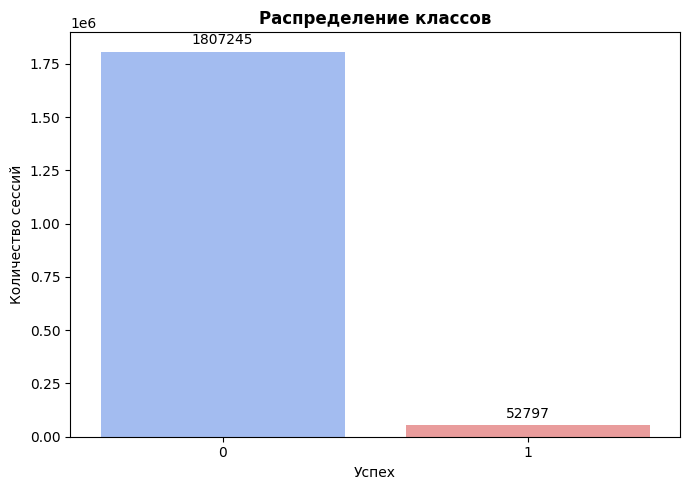

In [19]:
plt.figure(figsize=(7, 5))

countplot = sns.countplot(x=df["is_target"], hue=df["is_target"], palette=["#96b7fd", "#f68f8f"], legend=False)

for p in countplot.patches:
    countplot.annotate(
        f"{p.get_height():.0f}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', xytext=(0, 8), textcoords='offset points'
    )

plt.title('Распределение классов', weight='bold')
plt.xlabel('Успех')
plt.ylabel('Количество сессий')
plt.tight_layout()
plt.show()

Классы крайне асимметричны. Это необходимо учесть в выборе инструментов предобработки и метрик в обучении модели.

Посмотрим на изменение конверсии во времени.

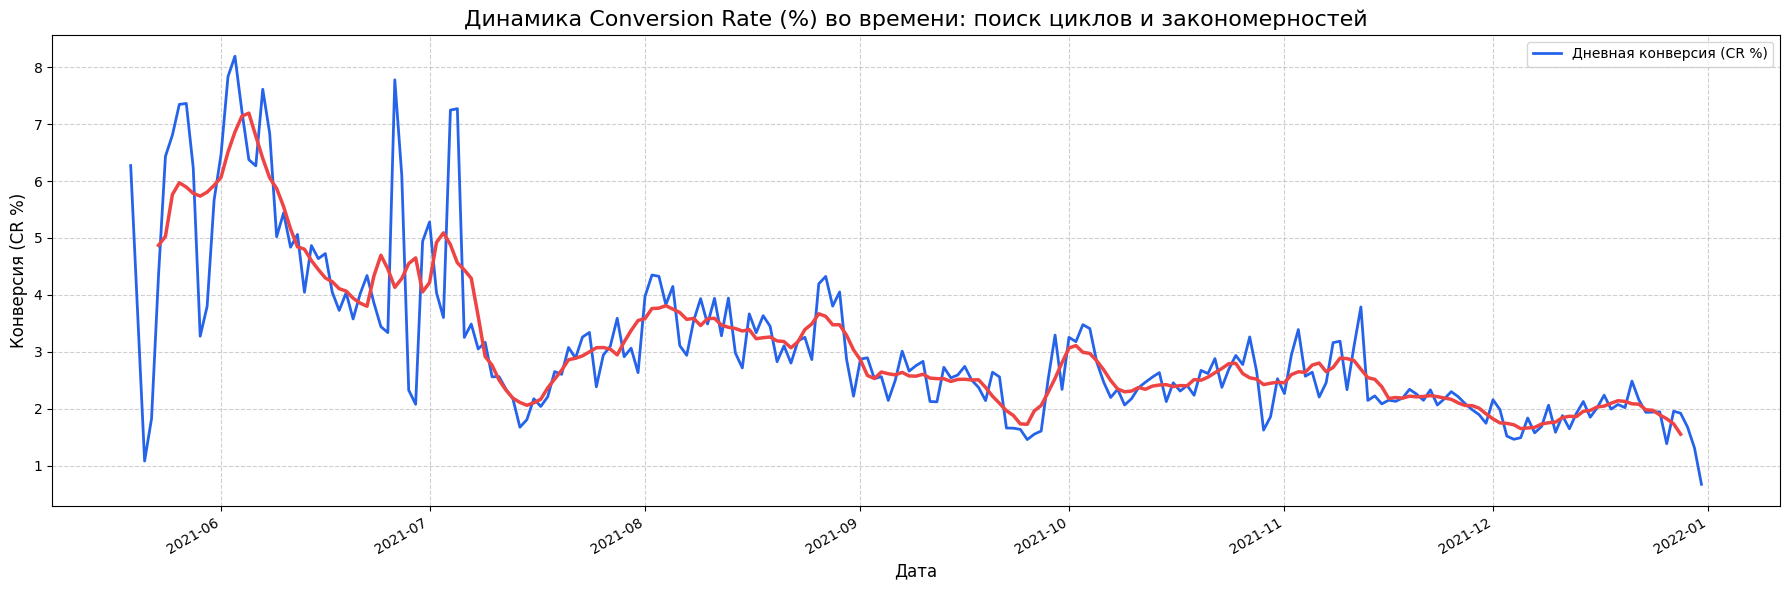

In [20]:
timeline_stats = df.groupby('visit_date').agg(
    total_sessions=('is_target', 'count'),
    conversion_rate=('is_target', 'mean')
).reset_index()

timeline_stats['visit_date'] = pd.to_datetime(timeline_stats['visit_date'])

timeline_stats['cr_%'] = timeline_stats['conversion_rate'] * 100

# Сортировка по хронологии
timeline_stats = timeline_stats.sort_values('visit_date').reset_index(drop=True)

plt.figure(figsize=(18, 6))

sns.lineplot(
    data=timeline_stats, 
    x='visit_date', 
    y='cr_%', 
    color='#2563eb', 
    linewidth=2, 
    label='Дневная конверсия (CR %)'
)

# Скользящее среднее за 7 дней
timeline_stats['cr_smoothed_7d'] = timeline_stats['cr_%'].rolling(window=7, center=True).mean()
plt.plot(
    timeline_stats['visit_date'], 
    timeline_stats['cr_smoothed_7d'], 
    color='#ef4444', 
    linewidth=2.5, 
    linestyle='-', 
    label='7-дневный сглаженный тренд'
)

plt.title('Динамика Conversion Rate (%) во времени: поиск циклов и закономерностей', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Конверсия (CR %)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.6)

plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

На графике прослеживается глобальный нисходящий тренд. Он июня 2021-го года и до января 2022. Это может означать сезонный пик в начале лета. Нет четкой месячной цикличности, то есть конверсия не зависит от дня месяца (например дня зарплаты или аванса).

Возьмем данные за сентябрь (относительно стабильный месяц на графике) и построим тренд по нему, чтобы увидеть цикличность по дням недели.

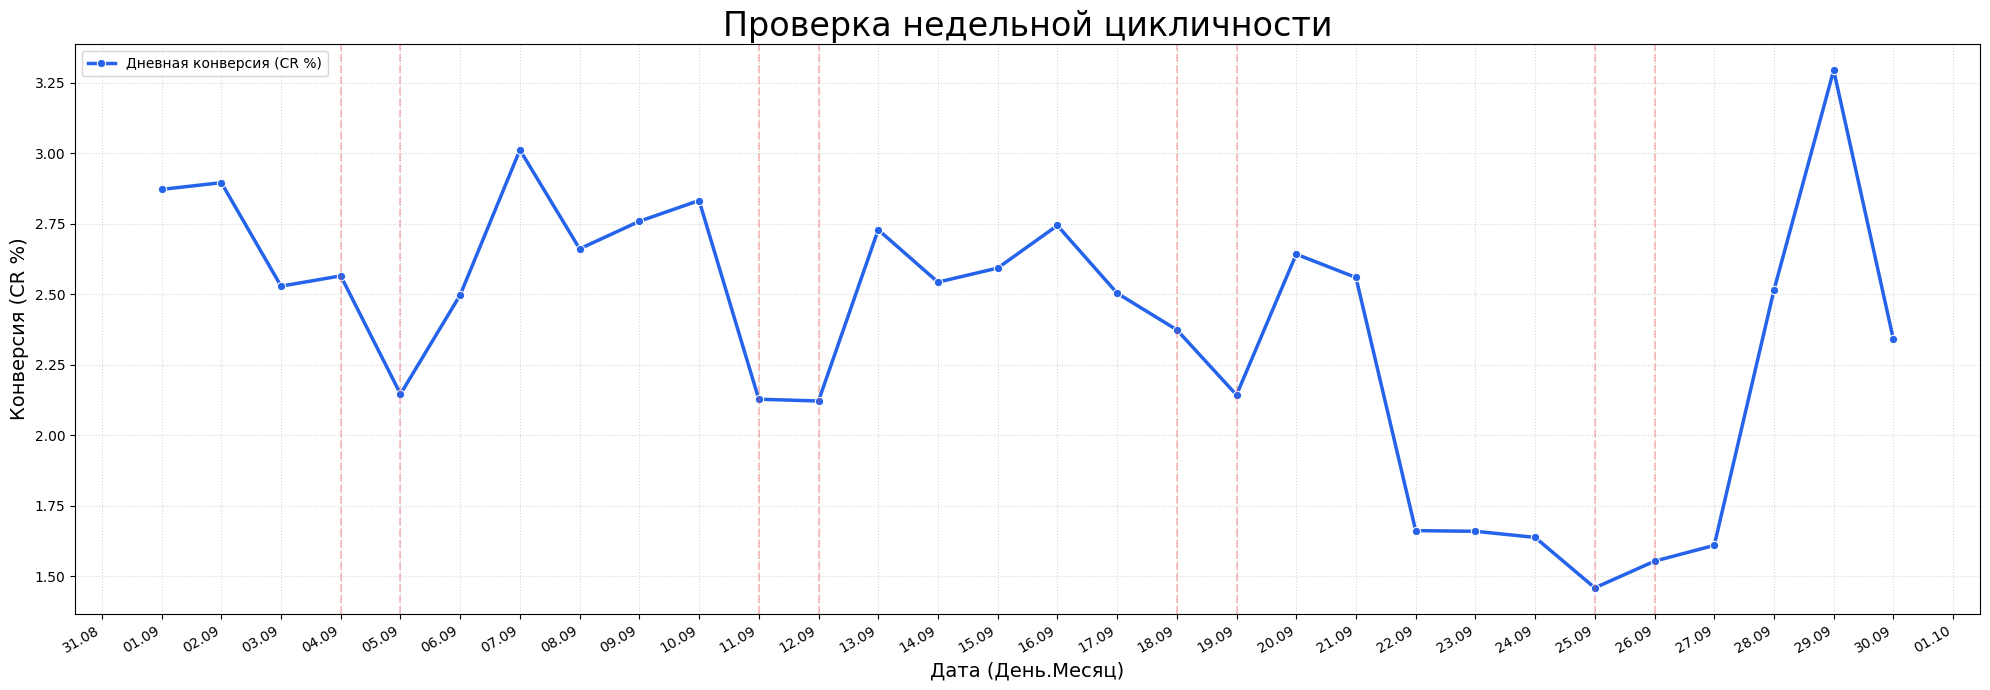

In [21]:
monthly_detail = timeline_stats[
    (timeline_stats['visit_date'] >= '2021-09-01') & 
    (timeline_stats['visit_date'] <= '2021-09-30')
].copy()

monthly_detail['day_of_week'] = monthly_detail['visit_date'].dt.dayofweek

plt.figure(figsize=(20, 7))

sns.lineplot(
    data=monthly_detail, 
    x='visit_date', 
    y='cr_%', 
    color='#2563eb', 
    linewidth=2.5, 
    marker='o',
    label='Дневная конверсия (CR %)'
)

# !!! Подсветка выходных дней
for idx, row in monthly_detail.iterrows():
    if row['day_of_week'] in [5, 6]:
        plt.axvline(row['visit_date'], color='#ef4444', linestyle='--', alpha=0.3)

plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d.%m'))
plt.gcf().autofmt_xdate()

plt.title('Проверка недельной цикличности', fontsize=24)
plt.xlabel('Дата (День.Месяц)', fontsize=14)
plt.ylabel('Конверсия (CR %)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

График подтверждает наличие легкой недельной цикличности, падение конверсии в выходные и всплески в рабочие дни. Этот факт подсказывает нам идею для последующего feature engineering 

## Предобработка данных и Feature Engineering

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
import joblib

Разделим данные на признаки и таргет.

In [23]:
X = df.drop(columns=['is_target'])
y = df['is_target']

Делим данные на подвыборки для обучения и теста.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

Для pipeline предобработки было написано несколько классов. Они вынесены в отдельный скрипт src/transformers.py, это необходимо для того, чтобы модель смогла разворачиваться после десериализации. 

In [25]:
import os
import sys

sys.path.insert(0, os.path.abspath('src'))

"""
    Класс, для выявления скрытых пропусков в данных
"""
from src.transformers import StringAnomalyCleaner

"""
    Класс для кодирования категорий разрешения экрана в числовые признаки. 
    В результате работы этого класса мы получим три новых числовых признака 
    (ширина, высота, площадь), а исходный будет удален. 
    Пропуски будут заменены на медианные значения.
"""
from src.transformers import ScreenResolutionTransformer

"""
    Для предобработки категориального признака geo_city, 
    который содержит больше 2 тысяч категорий, опишем класс CityAgreggatorTransformer.
"""
from src.transformers import CityAgreggatorTransformer

"""
    Так же нам понадобится класс, для feature engineering временных меток. 
"""
from src.transformers import WebTimeFeatureExtractor

"""
    Класс, заполняющий пропуски в поле device_os, опираясь на данные из device_brand
"""
from src.transformers import BrandBasedOSImputer

"""
    Добавим класс, заполняющий оставшиеся пропуски в данных, кодирующий категориальные признаки, 
    и стандартизирующий наши данные.
    Для кодирования части категориальных признаков используем TargetEncoder, 
    который заменяет текст категориального признака на среднее значение целевой переменной, 
    то есть на процент конверсии. 
    Он так же оставит в признаках только нужные для обучения колонки, 
    и не вернет session_id и client_id, которые являются идентификаторами и для обучения не нужны.
"""
from src.transformers import FillerScalerDropper

## Разведочный анализ (EDA)

Создадим pipline для предобработки данных, и посмотрим на предобработанные данные в разрезе распределения и корреляции.

In [26]:
# Вначале используем большинство классов предобработки без финальной стандартизации
prescaler_pipeline = Pipeline([
    ('anomaly_cleaner', StringAnomalyCleaner()),              # Поиск стрытых пропусков 
    ('brand_os_imputer', BrandBasedOSImputer()),              # Заполняем пропуски в device_os
    ('city_aggregator', CityAgreggatorTransformer(top_n=30)), # Укрупняем справочник городов
    ('screen_transformer', ScreenResolutionTransformer()),    # Кодируем разрешение экрана
    ('time_extractor', WebTimeFeatureExtractor()),            # Добавляем новые признаки времени
])

# А кодирование и масштабирование оставим на следующий шаг
scaler_pipeline = Pipeline([
    ('scaler', FillerScalerDropper())
])


In [27]:
X_train_ps = prescaler_pipeline.fit_transform(X_train, y_train)

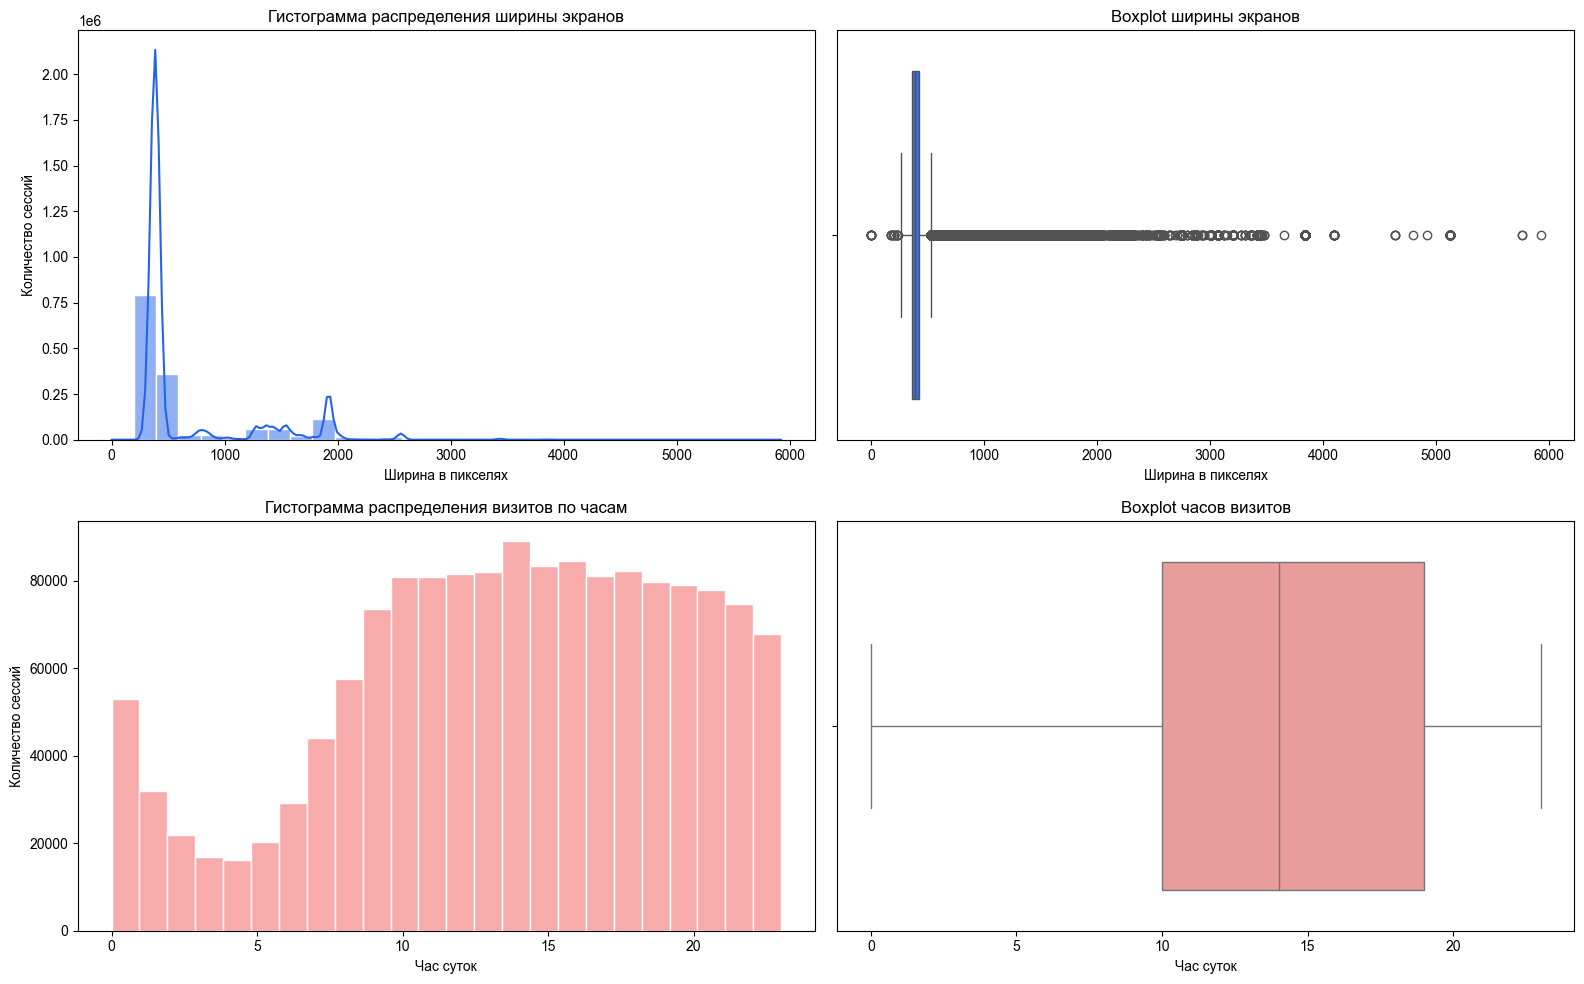

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.set_theme(style="whitegrid")

# --- Ширина экрана (screen_width) ---
sns.histplot(data=X_train_ps, x='screen_width', bins=30, kde=True, ax=axes[0, 0], color='#2563eb')
axes[0, 0].set_title('Гистограмма распределения ширины экранов')
axes[0, 0].set_xlabel('Ширина в пикселях')
axes[0, 0].set_ylabel('Количество сессий')

sns.boxplot(data=X_train_ps, x='screen_width', ax=axes[0, 1], color='#2563eb')
axes[0, 1].set_title('Boxplot ширины экранов')
axes[0, 1].set_xlabel('Ширина в пикселях')

# --- Час визита (visit_hour) ---
sns.histplot(data=X_train_ps, x='visit_hour', bins=24, kde=False, ax=axes[1, 0], color="#f68f8f")
axes[1, 0].set_title('Гистограмма распределения визитов по часам')
axes[1, 0].set_xlabel('Час суток')
axes[1, 0].set_ylabel('Количество сессий')

sns.boxplot(data=X_train_ps, x='visit_hour', ax=axes[1, 1], color="#f68f8f")
axes[1, 1].set_title('Boxplot часов визитов')
axes[1, 1].set_xlabel('Час суток')

plt.tight_layout()
plt.show()

На гистограмме Ширины экрана четко выделяется пик, в области 300-500 пикселей. Следовательно подавляющее большинство пользователей «СберАвтоподписки» заходят в сервис со смартфонов. И небольшие пики показывают количество пользователей, использующих ноутбуки и большие мониторы стационарных компьютеров. 

По графикам визитов видно, что ночью (01:00 - 06:00) активность пользователей падает до минимума. А Boxplot показывает, что медиана распределения приходится ровно на 14 часов, так же как и пик дневной активности.

Посмотрим на конверсии в разрезе типа трафика: Органического/неорганического 

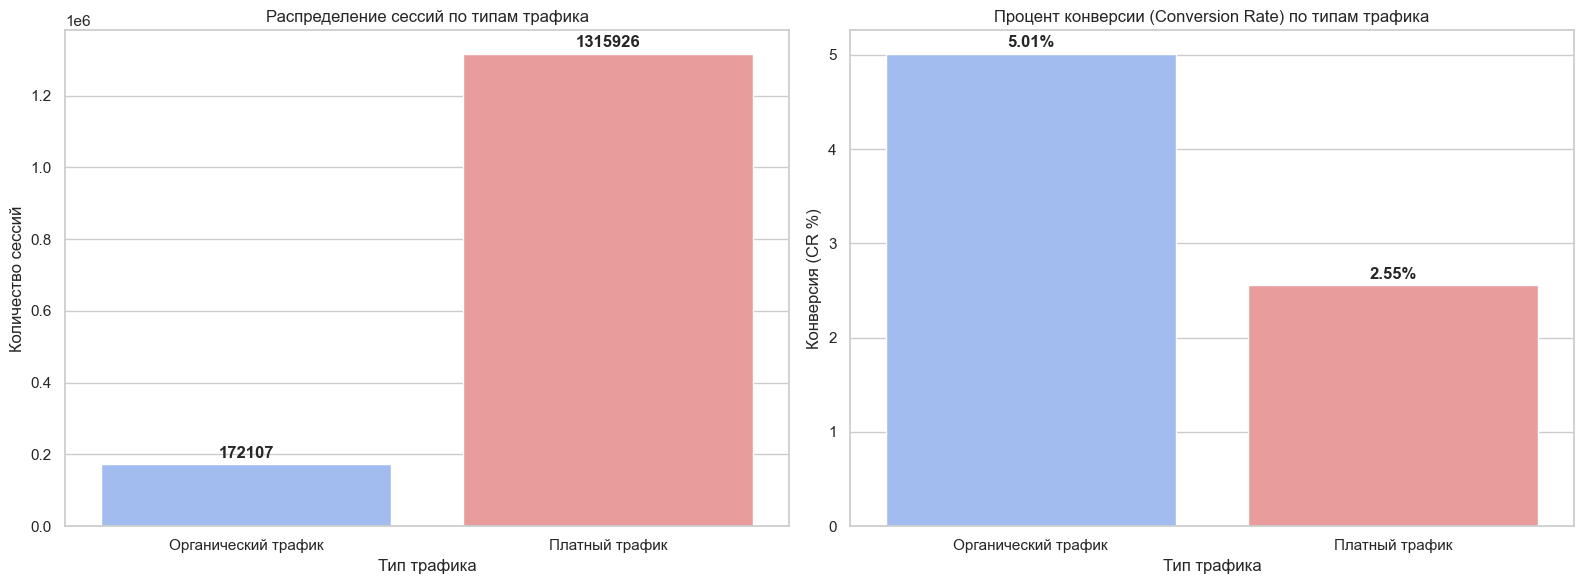

In [29]:
organic_labels = ['organic', 'referral', '(none)', 'none']
df_sample = X_train_ps.copy()

df_sample['traffic_type'] = np.where(
    df_sample['utm_medium'].isin(organic_labels), 
    'Органический трафик', 
    'Платный трафик'
)
df_sample = pd.concat([df_sample, y_train], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

traffic = df_sample.groupby('traffic_type')['session_id'].count().reset_index()
barplot = sns.barplot(
    data=traffic, 
    x='traffic_type', 
    y='session_id',
    hue='traffic_type', 
    palette=["#96b7fd", "#f68f8f"],
    ax=axes[0]
)
# Добавляем точные подписи процентов над столбцами
for p in barplot.patches:
    barplot.annotate(
        f"{p.get_height():.0f}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', xytext=(0, 8), textcoords='offset points', weight='bold'
    )

axes[0].set_title('Распределение сессий по типам трафика')
axes[0].set_xlabel('Тип трафика')
axes[0].set_ylabel('Количество сессий')

# Конверсия в процентах для каждого типа
traffic_cr = df_sample.groupby('traffic_type')['is_target'].mean().reset_index()
traffic_cr['conversion'] = traffic_cr['is_target'] * 100

barplot = sns.barplot(
    data=traffic_cr, 
    x='traffic_type', 
    y='conversion',
    hue='traffic_type', 
    palette=["#96b7fd", "#f68f8f"],
    ax=axes[1]
)

# Добавляем точные подписи процентов над столбцами
for p in barplot.patches:
    barplot.annotate(
        f"{p.get_height():.2f}%", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', xytext=(0, 8), textcoords='offset points', weight='bold'
    )

axes[1].set_title('Процент конверсии (Conversion Rate) по типам трафика')
axes[1].set_xlabel('Тип трафика')
axes[1].set_ylabel('Конверсия (CR %)')

# plt.ylim(0, traffic_cr['conversion'].max() * 1.2)
plt.tight_layout()
plt.show()


Платный трафик составляет около 88% общего объема. И хотя конверсия платного трафика почти в 2 раза ниже конверсии органического, в абсолютных цифрах платный трафик приносит почти 80% всех коневерсий сервиса.  

### Тепловая карта корреляций признаков для будущей модели.
Для построения тепловой карты корреляциции необходимо добавить финальный шаг к пайплайну - закодировать и стандартизировать категориальные данные.

In [30]:
X_train_s = scaler_pipeline.fit_transform(X_train_ps, y_train)

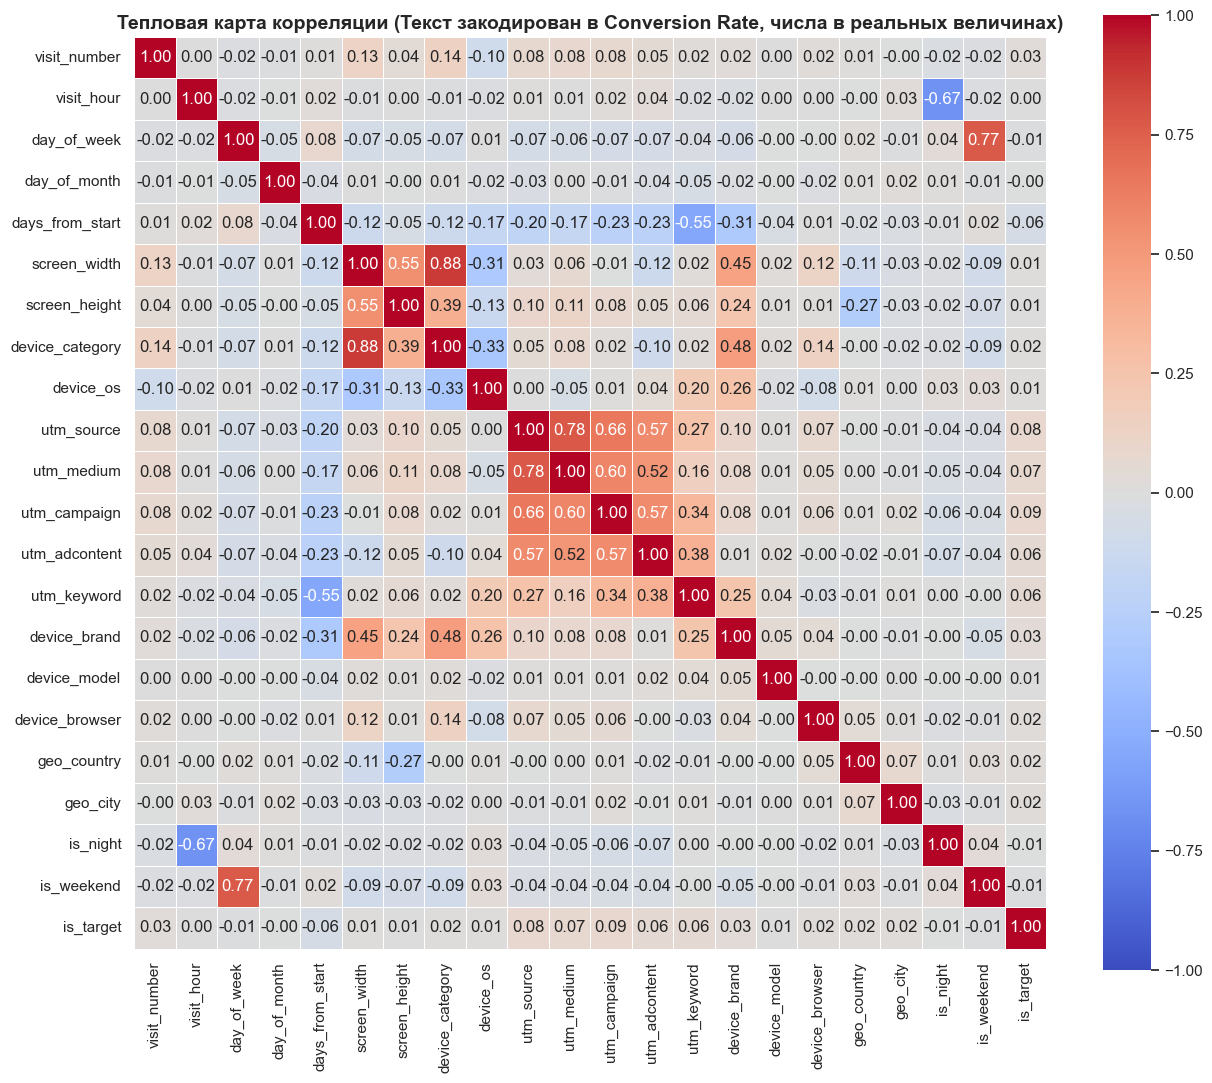

In [31]:
df_readable_corr = pd.concat([X_train_s, y_train], axis=1)

plt.figure(figsize=(13, 11))
sns.heatmap(
    df_readable_corr.corr(method='pearson'), # Используем стандартную корреляцию Пирсона
    annot=True,             
    fmt='.2f',              
    cmap='coolwarm',        
    vmin=-1, vmax=1,        
    linewidths=0.5,         
    square=True             
)

plt.title('Тепловая карта корреляции (Текст закодирован в Conversion Rate, числа в реальных величинах)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

Ширина экрана (screen_width) сильно скоррелирована с категорией устройства (device_category). Коэффициент корреляции 0.89. Так же зависимы столбцы utm_source и utm_medium (коэффициент 0.81). А вот таргет попарно линейно независим от всего набора признаков. 

Интересно, что обнаружилась корреляция медлу days_from_start и utm_keyword (-0.53).

## Обучим несколько моделей

Проведем предобработку данных и создадим сетки параметров для двух быстрых моделей классификации.

In [32]:
# обработаем тест уже обученными пайплайнами, для проверки расчетов моделей
X_test_ps = prescaler_pipeline.transform(X_test)
X_test_s = scaler_pipeline.transform(X_test_ps)

In [33]:
param_distributions = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
        "params": {"C": [0.1, 1.0, 10.0]}
    },

    "LightGBM": {
        "model": LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced', verbose=-1),
        "params": {"learning_rate": [0.01, 0.1], "n_estimators": [100, 200]}
    }
}

In [34]:
best_models = {}
for name, config in param_distributions.items():
    print(f"\n  Модель: {name}")
    print("="*50)
    
    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=3,
        scoring="roc_auc",
        n_jobs=1
    )
    
    grid_search.fit(X_train_s, y_train)
    
    # Оцениваем лучшую модель на тестовой выборке
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    preds = best_model.predict(X_test_s)
    probs = best_model.predict_proba(X_test_s)[:, 1]

    print(f"    Лучшие параметры: {grid_search.best_params_}")
    print(f"    ROC-AUC на тестовой выборке: {roc_auc_score(y_test, probs):.4f}")


  Модель: LogisticRegression
    Лучшие параметры: {'C': 10.0}
    ROC-AUC на тестовой выборке: 0.6605

  Модель: LightGBM
    Лучшие параметры: {'learning_rate': 0.1, 'n_estimators': 200}
    ROC-AUC на тестовой выборке: 0.7151


Лучшая метрика ROC-AUC получена на модели LightGBM с параметрами {'learning_rate': 0.1, 'n_estimators': 200}. 

## Финальный Pipeline

Создадим финальный pipline с лучшей моделью. И обучим его на полных данных.

In [35]:
lgbm_pipeline = Pipeline([
    ('anomaly_cleaner', StringAnomalyCleaner()),              # Поиск стрытых пропусков 
    ('brand_os_imputer', BrandBasedOSImputer()),              # Заполняем пропуски в device_os
    ('city_aggregator', CityAgreggatorTransformer(top_n=30)), # Укрупняем справочник городов
    ('screen_transformer', ScreenResolutionTransformer()),    # Кодируем разрешение экрана
    ('time_extractor', WebTimeFeatureExtractor()),            # Добавляем новые признаки времени
    ('preprocessor', FillerScalerDropper()),                  # Автозаполнение оставшихся пропусков и кодирование категориальных признаков
    ('classifier', LGBMClassifier(n_estimators=200, learning_rate=0.1, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
])

lgbm_pipeline.fit(X, y)

,steps,"[('anomaly_cleaner', ...), ('brand_os_imputer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,top_n,30
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000


In [36]:
# сохраним готовый pipline
joblib.dump(lgbm_pipeline, 'models/model.pkl')

['models/model.pkl']

Для теста сервиса (а не качества предсказания модели) выгрузим небольшой сэмпл иксов в файл.

In [38]:
test_sample = X.sample(100, random_state=RANDOM_STATE)
test_sample.to_csv('data/test_sample.csv', index=False)

## Выводы

### Бизнес-эффект и ценность решения
1. Автоматизация скоринга: Разработанный сервис позволяет в режиме реального времени предсказывать вероятность совершения целевого действия пользователем прямо во время его визита.
2. Персонализация контента: На основе скоринга модели сайт может динамически предлагать спецпредложения или подписки пользователям с высоким потенциалом конверсии (prediction = 1).

### Что можно улучшить
* Настроить еще более глубокую генерацию признаков (Feature Engineering).
* Протестировать методы оверсэмплинга (SMOTE) для более качественного обучения минорного класса.
* Оптимизировать время отклика API (провести рефакторинг кастомных трансформеров для снижения Latency).